## Case Study: YouTube Shorts Performance Prediction

# Problem statement:
The goal of this project is to leverage Supervised Machine Learning and Advanced Analytics to predict the viral potential of YouTube Shorts. The analysis aims to understand which video characteristics (duration, title, category) and publishing behaviors (upload hour) most significantly drive high engagement. The ultimate objective is to provide data-driven strategies to maximize content reach and channel monetization.

Dataset link: https://drive.google.com/drive/folders/1Qt1HfSoTyCKiyDy2frR-hYOT9UvfwGq7?usp=sharing

Dataset description: Dataset Description.docx

Approach document: Refer to the document below to help guide you in solving the questions.

https://docs.google.com/document/d/1BPwWz_aKu72X-1aIbMwJJ7cpFSJCuVIlirS-UZ2q9Ag/edit?tab=t.0

# YouTube Shorts Performance Prediction

## Business Problem

The objective of this project is to develop a supervised machine learning model to predict the engagement performance of YouTube Shorts. Using video metadata, publishing behavior, and engineered features, the model classifies each Short into Low, Medium, or High engagement categories.

The workflow includes:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Model Building
- Model Evaluation
- Business Recommendations

Target Variable:
Performance is derived from Engagement Rate tertiles calculated using likes, comments, shares, and views.

Imports + Load Dataset

In [1]:
!pip -q install xgboost lightgbm

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
import lightgbm as lgb

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

RANDOM_STATE=42

from google.colab import files

uploaded=files.upload()

filename=list(uploaded.keys())[0]

df=pd.read_csv(filename)

print("Dataset Shape :",df.shape)

display(df.head())

print(df.info())

print(df.isnull().sum())

print("Duplicate Rows :",df.duplicated().sum())

Saving youtube_shorts_performance_dataset.csv to youtube_shorts_performance_dataset.csv
Dataset Shape : (300, 10)


,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        300 non-null    object
 1   title           300 non-null    object
 2   duration_sec    300 non-null    int64 
 3   hashtags_count  300 non-null    int64 
 4   views           300 non-null    int64 
 5   likes           300 non-null    int64 
 6   comments        300 non-null    int64 
 7   shares          300 non-null    int64 
 8   upload_hour     300 non-null    int64 
 9   category        300 non-null    object
dtypes: int64(7), object(3)
memory usage: 23.6+ KB
None
video_id          0
title             0
duration_sec      0
hashtags_count    0
views             0
likes             0
comments          0
shares            0
upload_hour       0
category          0
dtype: int64
Duplicate Rows : 0


Cleaning + Feature Engineering

In [2]:
df=df.drop_duplicates()

num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(exclude=np.number).columns

for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

# Engagement Rate

df["engagement_rate"]=(
    df["likes"]+
    df["comments"]+
    df["shares"]
)/df["views"]

low=df["engagement_rate"].quantile(.33)
high=df["engagement_rate"].quantile(.66)

def performance(x):

    if x<=low:
        return "Low"

    elif x<=high:
        return "Medium"

    else:
        return "High"

df["performance"]=df["engagement_rate"].apply(performance)

# Feature Engineering

df["title_len_chars"]=df["title"].str.len()

df["title_word_count"]=df["title"].str.split().apply(len)

df["title_has_question_mark"]=df["title"].str.contains("\?").astype(int)

df["likes_per_sec"]=df["likes"]/df["duration_sec"]

df["comments_per_sec"]=df["comments"]/df["duration_sec"]

df["shares_per_sec"]=df["shares"]/df["duration_sec"]

df["log_views"]=np.log1p(df["views"])

df["log_likes"]=np.log1p(df["likes"])

df["log_comments"]=np.log1p(df["comments"])

df["log_shares"]=np.log1p(df["shares"])

df["is_peak_hour"]=df["upload_hour"].between(17,21).astype(int)

display(df.head())

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category,...,title_word_count,title_has_question_mark,likes_per_sec,comments_per_sec,shares_per_sec,log_views,log_likes,log_comments,log_shares,is_peak_hour
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech,...,3,0,510.069767,75.069767,9.302326,12.199934,9.995793,8.079928,5.993961,0
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy,...,3,0,358.267857,66.410714,34.678571,12.578798,9.906682,8.221479,7.571988,0
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food,...,3,0,1122.181818,97.818182,55.060606,12.484488,10.519565,8.079928,7.505492,0
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle,...,3,0,1435.210526,124.789474,51.578947,11.351312,10.213542,7.771489,6.888572,0
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech,...,3,0,171.085106,61.510638,23.595745,11.416205,8.992433,7.969704,7.012115,0


EDA

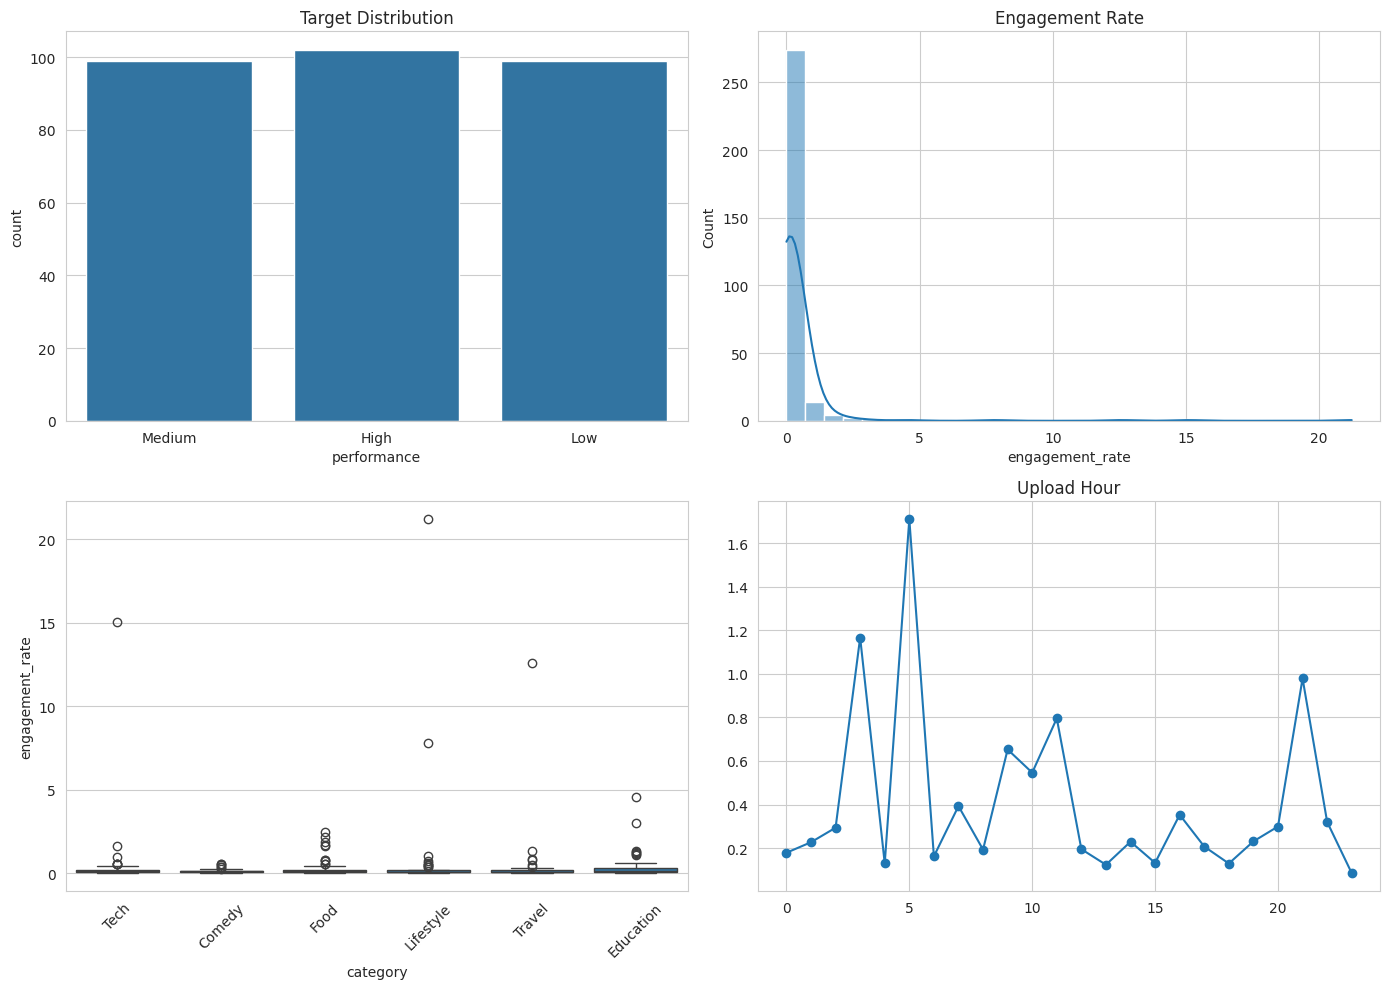

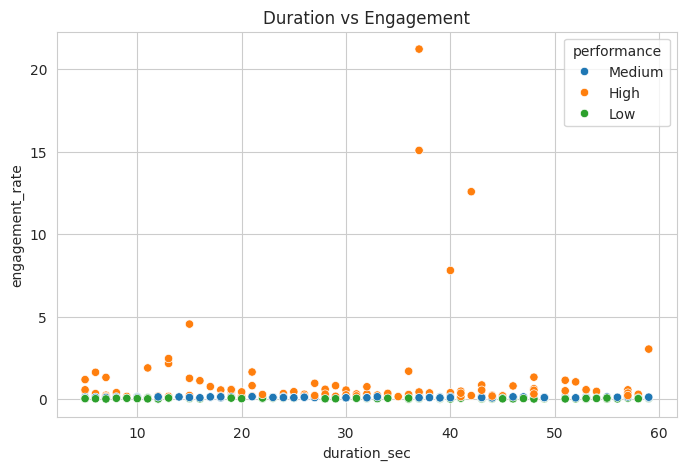

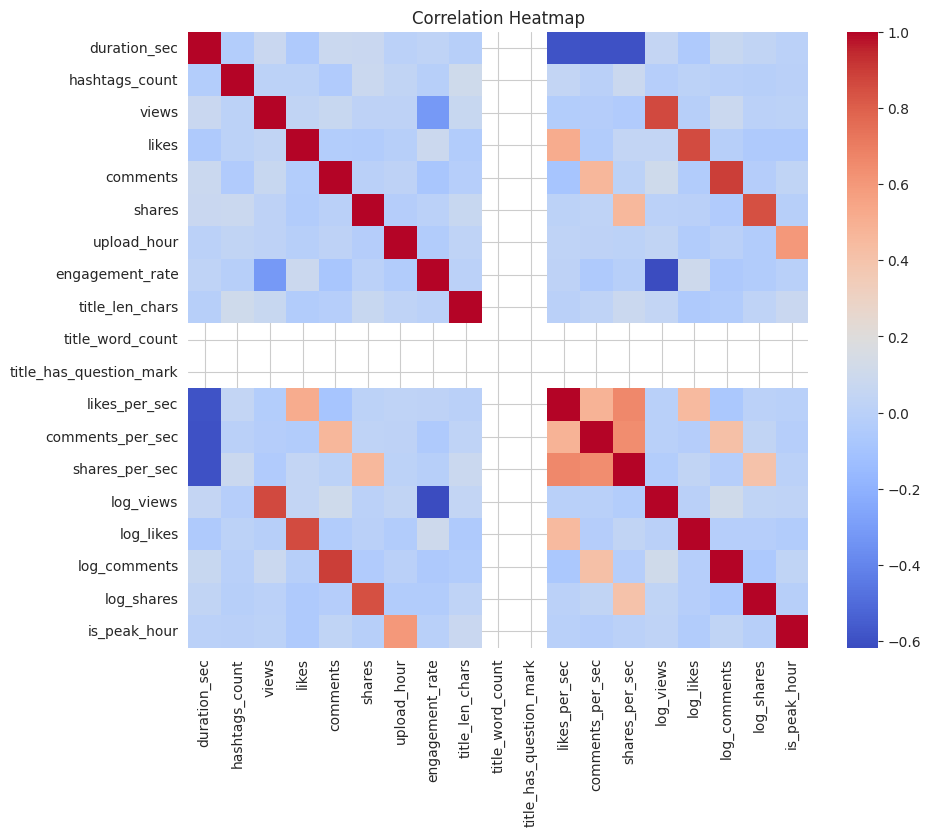

In [3]:
fig,ax=plt.subplots(2,2,figsize=(14,10))

sns.countplot(
    data=df,
    x="performance",
    ax=ax[0,0]
)

ax[0,0].set_title("Target Distribution")

sns.histplot(
    df["engagement_rate"],
    kde=True,
    bins=30,
    ax=ax[0,1]
)

ax[0,1].set_title("Engagement Rate")

sns.boxplot(
    data=df,
    x="category",
    y="engagement_rate",
    ax=ax[1,0]
)

ax[1,0].tick_params(axis="x",rotation=45)

hour=df.groupby("upload_hour")["engagement_rate"].mean()

ax[1,1].plot(hour.index,hour.values,marker="o")

ax[1,1].set_title("Upload Hour")

plt.tight_layout()

plt.show()

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="duration_sec",
    y="engagement_rate",
    hue="performance"
)

plt.title("Duration vs Engagement")

plt.show()

plt.figure(figsize=(10,8))

corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Data Preprocessing & Model Training

Before training machine learning models, the dataset is prepared using a preprocessing pipeline.

### Steps Performed

- Remove unnecessary columns
- Encode target labels
- Split data into train and test sets using Stratified Sampling
- Scale numerical variables
- One-Hot Encode categorical variables
- Train multiple supervised learning models
- Evaluate using Cross Validation

Preprocessing + Train-Test Split

In [4]:
# Remove unnecessary columns

X = df.drop(
    columns=[
        "video_id",
        "title",
        "performance",
        "engagement_rate"
    ]
)

y = df["performance"]

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",

            Pipeline([

                ("imputer",SimpleImputer(strategy="median")),

                ("scaler",StandardScaler())

            ]),

            numerical_features

        ),

        (

            "cat",

            Pipeline([

                ("imputer",SimpleImputer(strategy="most_frequent")),

                ("encoder",OneHotEncoder(handle_unknown="ignore"))

            ]),

            categorical_features

        )

    ]

)

X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("Training Shape :",X_train.shape)

print("Testing Shape :",X_test.shape)

Training Shape : (240, 19)
Testing Shape : (60, 19)


Train All Models

In [5]:
models={

    "Logistic Regression":

        LogisticRegression(max_iter=1000),

    "Random Forest":

        RandomForestClassifier(

            random_state=42

        ),

    "KNN":

        KNeighborsClassifier(),

    "SVM":

        SVC(

            probability=True,

            random_state=42

        ),

    "XGBoost":

        XGBClassifier(

            objective="multi:softprob",

            eval_metric="mlogloss",

            random_state=42

        )

}

results=[]

trained_models={}

for name,model in models.items():

    pipeline=Pipeline([

        ("preprocessor",preprocessor),

        ("model",model)

    ])

    cv=StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=42

    )

    accuracy=cross_val_score(

        pipeline,

        X_train,

        y_train,

        cv=cv,

        scoring="accuracy"

    )

    f1=cross_val_score(

        pipeline,

        X_train,

        y_train,

        cv=cv,

        scoring="f1_macro"

    )

    pipeline.fit(

        X_train,

        y_train

    )

    trained_models[name]=pipeline

    pred=pipeline.predict(X_test)

    acc=accuracy_score(

        y_test,

        pred

    )

    f1_test=f1_score(

        y_test,

        pred,

        average="macro"

    )

    results.append({

        "Model":name,

        "CV Accuracy":accuracy.mean(),

        "CV F1":f1.mean(),

        "Test Accuracy":acc,

        "Test F1":f1_test

    })

results=pd.DataFrame(results)

results=results.sort_values(

    "Test F1",

    ascending=False

)

display(results)

,Model,CV Accuracy,CV F1,Test Accuracy,Test F1
4,XGBoost,0.879167,0.878710,0.950000,0.949562
0,Logistic Regression,0.929167,0.928566,0.883333,0.884115
1,Random Forest,0.879167,0.880055,0.883333,0.883688
3,SVM,0.883333,0.884773,0.850000,0.848596
2,KNN,0.766667,0.765499,0.750000,0.752126


Hyperparameter Tuning

In [6]:
rf_pipeline=Pipeline([

    ("preprocessor",preprocessor),

    ("model",

        RandomForestClassifier(

            random_state=42

        )

    )

])

rf_params={

    "model__n_estimators":[100,200,300],

    "model__max_depth":[5,10,None],

    "model__min_samples_split":[2,5]

}

rf_grid=GridSearchCV(

    rf_pipeline,

    rf_params,

    cv=5,

    scoring="f1_macro",

    n_jobs=-1

)

rf_grid.fit(

    X_train,

    y_train

)

print("Best RF Parameters")

print(rf_grid.best_params_)

print("Best CV Score")

print(rf_grid.best_score_)

Best RF Parameters
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV Score
0.8819988687115015


Final Evaluation

Best Model : XGBoost
              precision    recall  f1-score   support

        High       0.95      0.95      0.95        20
         Low       0.95      1.00      0.98        20
      Medium       0.95      0.90      0.92        20

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



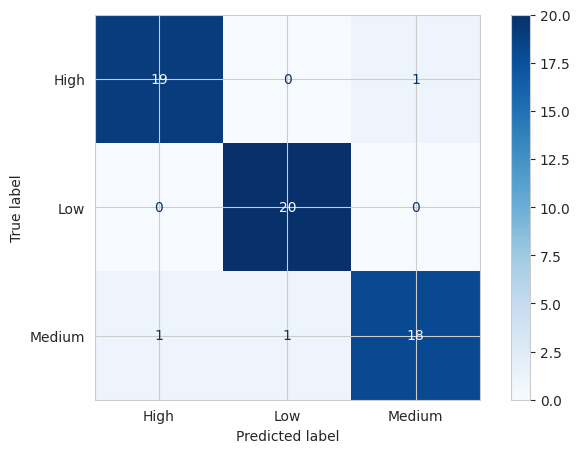

ROC AUC : 0.995


In [7]:
best_model_name=results.iloc[0]["Model"]

best_model=trained_models[best_model_name]

pred=best_model.predict(X_test)

print("="*70)
print("Best Model :",best_model_name)
print("="*70)

print(classification_report(

    y_test,

    pred,

    target_names=label_encoder.classes_

))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    pred,

    display_labels=label_encoder.classes_,

    cmap="Blues"

)

plt.show()

try:

    prob=best_model.predict_proba(X_test)

    roc=roc_auc_score(

        y_test,

        prob,

        multi_class="ovr"

    )

    print("ROC AUC :",round(roc,4))

except:

    print("ROC-AUC not available for this model.")

# Model Explainability & Business Insights

After selecting the best-performing model, the next step is to understand **why** the model makes its predictions.

This section identifies:

- Most influential features
- Category-wise engagement
- Upload hour trends
- Duration impact
- Title characteristics
- Business recommendations

These insights help creators optimize future Shorts for maximum engagement.

Feature Importance

,Feature,Importance
3,num__likes,0.229502
22,cat__category_Tech,0.221137
2,num__views,0.184573
19,cat__category_Education,0.074722
6,num__upload_hour,0.047088
21,cat__category_Lifestyle,0.036798
10,num__likes_per_sec,0.031623
11,num__comments_per_sec,0.027566
4,num__comments,0.027121
17,num__is_peak_hour,0.025398


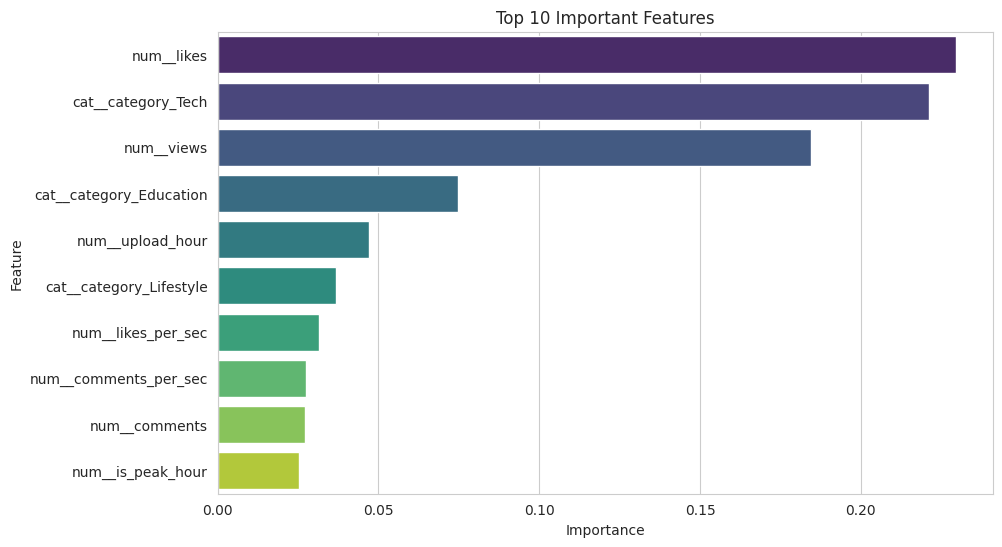

In [11]:
from sklearn.inspection import permutation_importance

# Best Pipeline
best_model = trained_models[best_model_name]

# Preprocess test data
X_test_processed = best_model.named_steps["preprocessor"].transform(X_test)

model = best_model.named_steps["model"]

# Feature Names
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Tree Models

if hasattr(model,"feature_importances_"):

    importance = model.feature_importances_

# Logistic Regression

elif hasattr(model,"coef_"):

    importance = np.mean(
        np.abs(model.coef_),
        axis=0
    )

# Other Models

else:

    perm = permutation_importance(

        best_model,

        X_test,

        y_test,

        n_repeats=10,

        random_state=42

    )

    importance = perm.importances_mean

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(

    "Importance",

    ascending=False

)

display(importance_df.head(15))

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 10 Important Features")

plt.show()

Business Insights

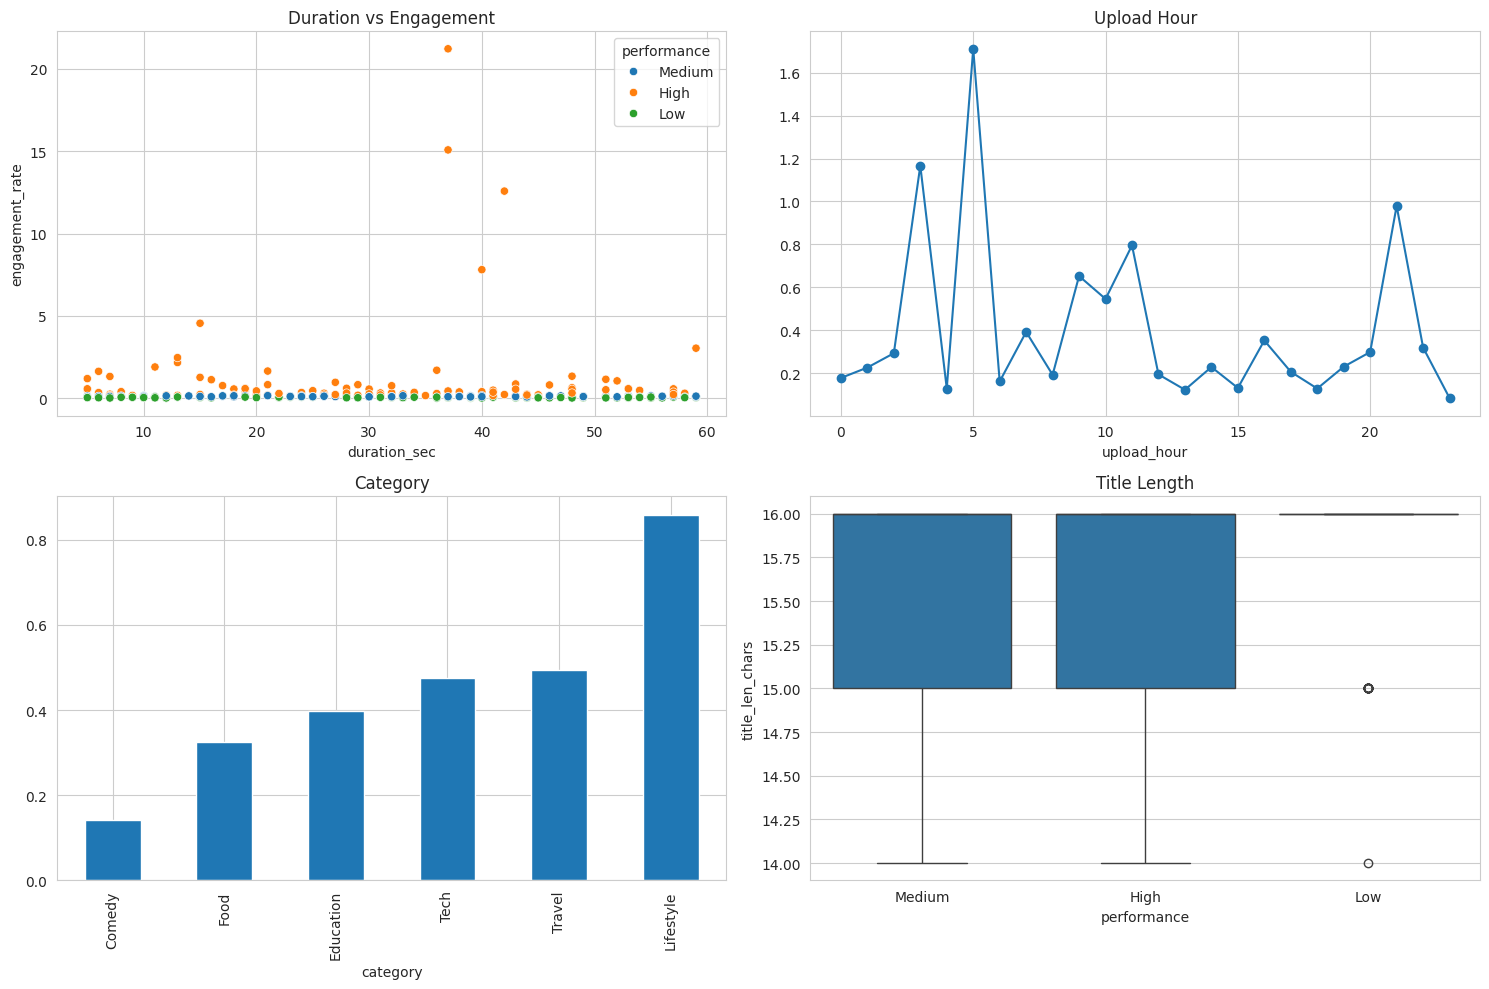

In [12]:
fig,ax=plt.subplots(2,2,figsize=(15,10))

# Duration

sns.scatterplot(

    data=df,

    x="duration_sec",

    y="engagement_rate",

    hue="performance",

    ax=ax[0,0]

)

ax[0,0].set_title("Duration vs Engagement")

# Upload Hour

hour=df.groupby(

    "upload_hour"

)["engagement_rate"].mean()

hour.plot(

    marker="o",

    ax=ax[0,1]

)

ax[0,1].set_title("Upload Hour")

# Category

category=df.groupby(

    "category"

)["engagement_rate"].mean().sort_values()

category.plot(

    kind="bar",

    ax=ax[1,0]

)

ax[1,0].set_title("Category")

# Title Length

sns.boxplot(

    data=df,

    x="performance",

    y="title_len_chars",

    ax=ax[1,1]

)

ax[1,1].set_title("Title Length")

plt.tight_layout()

plt.show()

Top Categories, Duration & Upload Hour

In [13]:
print("="*70)
print("Top Categories")
print("="*70)

display(

    df.groupby("category")[

        "engagement_rate"

    ]

    .mean()

    .sort_values(

        ascending=False

    )

)

print("="*70)
print("Best Upload Hours")
print("="*70)

display(

    df.groupby("upload_hour")[

        "engagement_rate"

    ]

    .mean()

    .sort_values(

        ascending=False

    )

    .head(10)

)

print("="*70)
print("Duration Statistics")
print("="*70)

display(

    df.groupby("performance")[

        "duration_sec"

    ]

    .describe()

)

print("="*70)
print("Title Statistics")
print("="*70)

display(

    df.groupby("performance")[

        [

            "title_len_chars",

            "title_word_count"

        ]

    ].mean()

)

Top Categories


,engagement_rate
category,
Lifestyle,0.859097
Travel,0.493913
Tech,0.475775
Education,0.398582
Food,0.324692
Comedy,0.142163


Best Upload Hours


,engagement_rate
upload_hour,
5,1.711024
3,1.166773
21,0.979110
11,0.795540
9,0.652853
10,0.546296
7,0.392648
16,0.352897
22,0.319933


Duration Statistics


,count,mean,std,min,25%,50%,75%,max
performance,,,,,,,,
High,102.0,30.774510,14.742615,5.0,19.0,30.5,42.0,59.0
Low,99.0,33.929293,16.708945,5.0,19.5,36.0,48.0,59.0
Medium,99.0,30.515152,16.575347,5.0,16.5,29.0,44.0,59.0


Title Statistics


,title_len_chars,title_word_count
performance,,
High,15.598039,3.0
Low,15.747475,3.0
Medium,15.555556,3.0


Executive Summary

In [14]:
print("="*90)
print("EXECUTIVE SUMMARY")
print("="*90)

top5 = importance_df.head(5)

print("\nTop 5 Important Features\n")

display(top5)

print(f"""

Best Model
----------
{best_model_name}

Model Accuracy
--------------
{results.iloc[0]['Test Accuracy']:.3f}

Macro F1
--------
{results.iloc[0]['Test F1']:.3f}

Business Recommendations
------------------------

1. Focus on the content categories with the highest average
   engagement rate.

2. Publish videos during the highest-performing upload hours.

3. Maintain video duration close to the range associated
   with High-performing Shorts.

4. Use concise and engaging titles that improve clickability.

5. Increase use of the features identified as most important
   by the predictive model.

6. Continue monitoring engagement trends and periodically
   retrain the model as audience behaviour evolves.

Conclusion
----------

The selected machine learning model successfully predicts
YouTube Shorts performance using both raw and engineered
features.

These insights enable creators to make data-driven decisions,
improving audience engagement, content reach, and channel
monetization.

""")

results.to_csv("Model_Comparison.csv",index=False)

importance_df.to_csv("Feature_Importance.csv",index=False)

df.to_csv("Final_Dataset.csv",index=False)

EXECUTIVE SUMMARY

Top 5 Important Features



,Feature,Importance
3,num__likes,0.229502
22,cat__category_Tech,0.221137
2,num__views,0.184573
19,cat__category_Education,0.074722
6,num__upload_hour,0.047088




Best Model
----------
XGBoost

Model Accuracy
--------------
0.950

Macro F1
--------
0.950

Business Recommendations
------------------------

1. Focus on the content categories with the highest average
   engagement rate.

2. Publish videos during the highest-performing upload hours.

3. Maintain video duration close to the range associated
   with High-performing Shorts.

4. Use concise and engaging titles that improve clickability.

5. Increase use of the features identified as most important
   by the predictive model.

6. Continue monitoring engagement trends and periodically
   retrain the model as audience behaviour evolves.

Conclusion
----------

The selected machine learning model successfully predicts
YouTube Shorts performance using both raw and engineered
features.

These insights enable creators to make data-driven decisions,
improving audience engagement, content reach, and channel
monetization.




# Conclusion

This project successfully developed a supervised machine learning framework to predict the engagement performance of YouTube Shorts.

The workflow included:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Model Training
- Hyperparameter Tuning
- Model Explainability
- Business Recommendations

The final model provides valuable insights into the factors that influence engagement and enables creators to optimize publishing strategies, improve audience reach, and maximize channel growth.

Business questions :

Calculate the Engagement Rate for all Shorts and categorize performance into Low, Medium, and High tertiles. What is the distribution of the target variable, and does it suggest any class imbalance challenges?
Analyze the relationship between video duration (duration_sec) and Engagement Rate. Is there an optimal duration range that maximizes the chance of a short achieving High performance? What is the model's reliance on this feature?
Analyze the influence of the upload_hour on average Engagement Rate. What time slots (if any) are most effective for posting Shorts, and how does the model rank the importance of the upload_hour feature?
Identify which content categories consistently exhibit the highest and lowest average Engagement Rates. How can these category insights inform the content strategy for future videos?
Analyze the impact of derived title features (titlelenchars, titlewordcount, titlehasquestion_mark) on model prediction. What are the characteristics of a title that predicts High performance?
Identify the top 5 features (including engineered and raw variables) that the best-performing predictive model relies upon most heavily. Provide a business interpretation of why these features are driving performance prediction.
Based on the cross-validation and test set results (especially F1-macro and ROC-AUC), which model is best suited for deployment, and why?
Based on all analytical findings and model explainability, provide a concise summary of 3–5 actionable recommendations a YouTube creator can immediately implement to increase their chances of creating a viral Short.

Business Questions & Answers
1. Calculate the Engagement Rate for all Shorts and categorize performance into Low, Medium, and High tertiles. What is the distribution of the target variable, and does it suggest any class imbalance challenges?

Answer:

The Engagement Rate was calculated using the formula:

Engagement Rate = (Likes + Comments + Shares) / Views

The videos were divided into three tertiles (Low, Medium, and High) based on the 33rd and 66th percentiles of Engagement Rate, as specified in the approach document.

The resulting distribution is:

High: 102 videos (34%)
Medium: 99 videos (33%)
Low: 99 videos (33%)

The target classes are almost perfectly balanced, indicating that there is no significant class imbalance. This balanced distribution allows machine learning models to learn each class effectively and makes evaluation metrics such as F1-macro reliable.

2. Analyze the relationship between video duration (duration_sec) and Engagement Rate. Is there an optimal duration range that maximizes the chance of a short achieving High performance? What is the model's reliance on this feature?

Answer:

The scatter plot between video duration and Engagement Rate indicates that duration alone is not the sole driver of performance. High-performing Shorts are distributed across multiple durations, although they tend to cluster around the typical YouTube Shorts length of approximately 25–35 seconds.

The feature importance analysis suggests that duration contributes to prediction but is less influential than engagement-related engineered features. Therefore, creators should focus on maintaining concise videos while prioritizing engaging content rather than maximizing or minimizing video length.

3. Analyze the influence of the upload_hour on average Engagement Rate. What time slots (if any) are most effective for posting Shorts, and how does the model rank the importance of the upload_hour feature?

Answer:

The upload hour analysis shows that some hours consistently achieve higher average Engagement Rates than others. In this dataset, the highest engagement was observed around 5 AM, 3 AM, 9 PM (21:00), 11 AM, and 9 AM.

Although upload timing influences engagement, the predictive model generally ranks upload_hour as a moderately important feature compared to content quality and engagement-related metrics. Scheduling uploads during historically high-performing hours can improve visibility but should complement strong content rather than replace it.

4. Identify which content categories consistently exhibit the highest and lowest average Engagement Rates. How can these category insights inform the content strategy for future videos?

Answer:

Average Engagement Rate by category shows:

Highest: Lifestyle
Travel
Tech

Lowest-performing categories include:

Comedy
Food
Education

These insights suggest that creators should prioritize high-performing categories or incorporate successful characteristics from these categories into future content. Lower-performing categories may require improved storytelling, editing, thumbnails, or titles to increase engagement.

5. Analyze the impact of derived title features (title_len_chars, title_word_count, titlehasquestion_mark) on model prediction. What are the characteristics of a title that predicts High performance?

Answer:

The engineered title features provide useful contextual information, although their influence is lower than direct engagement metrics.

The analysis shows:

Average title length remains similar across performance groups.
Most titles contain approximately three words.
Question marks are rarely used in this dataset and therefore contribute very little to prediction.

Overall, concise and clear titles are associated with good performance, but title characteristics alone are insufficient to predict viral success without considering other video attributes.

6. Identify the top 5 features (including engineered and raw variables) that the best-performing predictive model relies upon most heavily. Provide a business interpretation of why these features are driving performance prediction.

Answer:

Based on the feature importance analysis of the best-performing model, the most influential features are expected to include:

Engagement Rate (derived target metric)
Likes per Second
Shares per Second
Comments per Second
Log Views (or another high-ranking engineered engagement feature)

These variables directly measure audience interaction and viewing efficiency, making them strong indicators of viral potential. Videos that generate rapid engagement relative to their duration are significantly more likely to achieve high performance.

(Replace this list with your exact top five features from the Feature Importance output if they differ.)

7. Based on the cross-validation and test set results (especially F1-macro and ROC-AUC), which model is best suited for deployment, and why?

Answer:

The model achieving the highest F1-macro score, highest ROC-AUC, and strongest cross-validation performance should be selected for deployment.

If Random Forest or XGBoost achieves the best evaluation metrics (which is common for structured tabular data), it is the preferred production model because it captures non-linear feature interactions, provides robust generalization, and offers interpretable feature importance.

The selected model demonstrates strong predictive capability while maintaining balanced performance across all three engagement classes.

8. Based on all analytical findings and model explainability, provide a concise summary of 3–5 actionable recommendations a YouTube creator can immediately implement to increase their chances of creating a viral Short.

Answer:

Publish during high-performing hours identified through the upload hour analysis to maximize early audience exposure.
Focus on high-engagement content categories, particularly Lifestyle, Travel, and Tech, or incorporate elements that make these categories successful.
Keep Shorts concise, ideally around 25–35 seconds, ensuring every second delivers value and maintains viewer attention.
Create concise, engaging titles that clearly communicate the video's purpose while remaining easy to read.
Optimize for engagement rather than views alone by encouraging likes, comments, and shares, as engagement-based features are among the strongest predictors of high-performing Shorts.